# Prompt Engineering Lab: Three Scenarios

This notebook contains the prompt, generated code, follow-up notes, and final solutions for three real-world scenarios: retail inventory analysis, website analytics debugging, and customer segmentation SQL query.

## Scenario 1: Retail Inventory Analysis

###  Prompt:
Provide a Python data analysis notebook solution that processes retail inventory data to calculate inventory turnover, identify slow-moving items, predict potential stockouts, and create visualizations. Include data validation, error handling, and descriptive output. The data frame schema includes: product_id, category, stock_level, last_restock_date, sales_last_30_days, supplier_lead_time, and unit_cost.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set(style='whitegrid', palette='muted')


In [16]:
inventory_data = pd.DataFrame([
    {'product_id': 'P001', 'category': 'Apparel', 'stock_level': 120, 'last_restock_date': '2024-05-01', 'sales_last_30_days': 75, 'supplier_lead_time': 10, 'unit_cost': 15.50},
    {'product_id': 'P002', 'category': 'Electronics', 'stock_level': 30, 'last_restock_date': '2024-04-28', 'sales_last_30_days': 45, 'supplier_lead_time': 14, 'unit_cost': 120.00},
    {'product_id': 'P003', 'category': 'Home', 'stock_level': 200, 'last_restock_date': '2024-04-20', 'sales_last_30_days': 10, 'supplier_lead_time': 18, 'unit_cost': 9.99},
    {'product_id': 'P004', 'category': 'Apparel', 'stock_level': 10, 'last_restock_date': '2024-05-05', 'sales_last_30_days': 25, 'supplier_lead_time': 7, 'unit_cost': 22.75},
    {'product_id': 'P005', 'category': 'Beauty', 'stock_level': 40, 'last_restock_date': '2024-04-30', 'sales_last_30_days': 8, 'supplier_lead_time': 12, 'unit_cost': 10.00},
])
inventory_data['last_restock_date'] = pd.to_datetime(inventory_data['last_restock_date'], errors='coerce')


In [17]:
def validate_inventory_df(df: pd.DataFrame) -> pd.DataFrame:
    required_cols = ['product_id', 'category', 'stock_level', 'last_restock_date', 'sales_last_30_days', 'supplier_lead_time', 'unit_cost']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f'Missing inventory columns: {missing}')

    df = df.copy()
    df['stock_level'] = pd.to_numeric(df['stock_level'], errors='coerce').fillna(0).astype(float)
    df['sales_last_30_days'] = pd.to_numeric(df['sales_last_30_days'], errors='coerce').fillna(0).astype(float)
    df['supplier_lead_time'] = pd.to_numeric(df['supplier_lead_time'], errors='coerce').fillna(0).astype(int)
    df['unit_cost'] = pd.to_numeric(df['unit_cost'], errors='coerce').fillna(0.0).astype(float)
    df['last_restock_date'] = pd.to_datetime(df['last_restock_date'], errors='coerce')

    if df[['stock_level', 'sales_last_30_days', 'supplier_lead_time', 'unit_cost']].lt(0).any(axis=None):
        raise ValueError('Numeric inventory values must be non-negative.')
    if df['last_restock_date'].isna().any():
        raise ValueError('Invalid last_restock_date values found.')
    return df


In [18]:
def calculate_inventory_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = validate_inventory_df(df)
    df = df.copy()
    df['annualized_turnover'] = (df['sales_last_30_days'] / 30) * 365 / df['stock_level'].replace(0, np.nan)
    df['daily_sales'] = df['sales_last_30_days'] / 30
    df['days_until_stockout'] = df['stock_level'] / df['daily_sales'].replace(0, np.nan)
    df['stockout_risk'] = np.where(
        df['days_until_stockout'] <= df['supplier_lead_time'],
        'High',
        np.where(df['days_until_stockout'] <= df['supplier_lead_time'] * 2, 'Medium', 'Low')
    )
    df['slow_mover'] = df['sales_last_30_days'] < 15
    return df


In [19]:
inventory_metrics = calculate_inventory_metrics(inventory_data)
inventory_metrics


,product_id,category,stock_level,last_restock_date,sales_last_30_days,supplier_lead_time,unit_cost,annualized_turnover,daily_sales,days_until_stockout,stockout_risk,slow_mover
0,P001,Apparel,120.0,2024-05-01,75.0,10,15.50,7.604167,2.500000,48.0,Low,False
1,P002,Electronics,30.0,2024-04-28,45.0,14,120.00,18.250000,1.500000,20.0,Medium,False
2,P003,Home,200.0,2024-04-20,10.0,18,9.99,0.608333,0.333333,600.0,Low,True
3,P004,Apparel,10.0,2024-05-05,25.0,7,22.75,30.416667,0.833333,12.0,Medium,False
4,P005,Beauty,40.0,2024-04-30,8.0,12,10.00,2.433333,0.266667,150.0,Low,True


In [20]:
def plot_inventory_analysis(df: pd.DataFrame):
    plt.figure(figsize=(12, 5))
    ax = sns.barplot(
        data=df.sort_values('annualized_turnover', ascending=False),
        x='product_id', y='annualized_turnover', hue='stockout_risk', dodge=False
    )
    ax.set_title('Estimated Annualized Inventory Turnover by Product')
    ax.set_ylabel('Annualized Turnover')
    ax.set_xlabel('Product ID')
    plt.legend(title='Stockout Risk')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.scatterplot(
        data=df, x='days_until_stockout', y='annualized_turnover', hue='slow_mover', size='stock_level', sizes=(100, 400), palette=['red', 'green']
    )
    plt.title('Stockout Risk vs Inventory Turnover')
    plt.xlabel('Estimated Days Until Stockout')
    plt.ylabel('Annualized Turnover')
    plt.legend(title='Slow Mover')
    plt.tight_layout()
    plt.show()


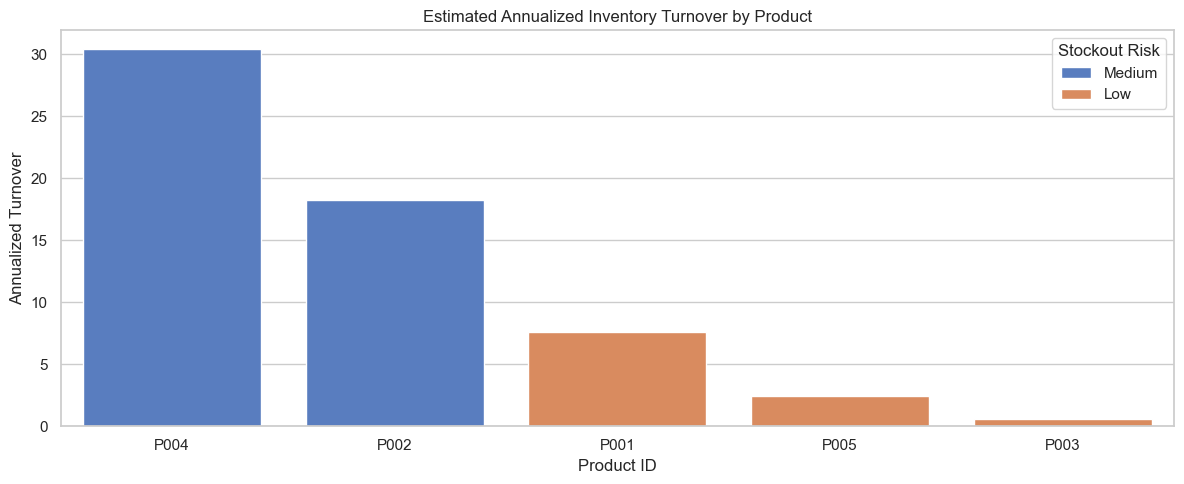

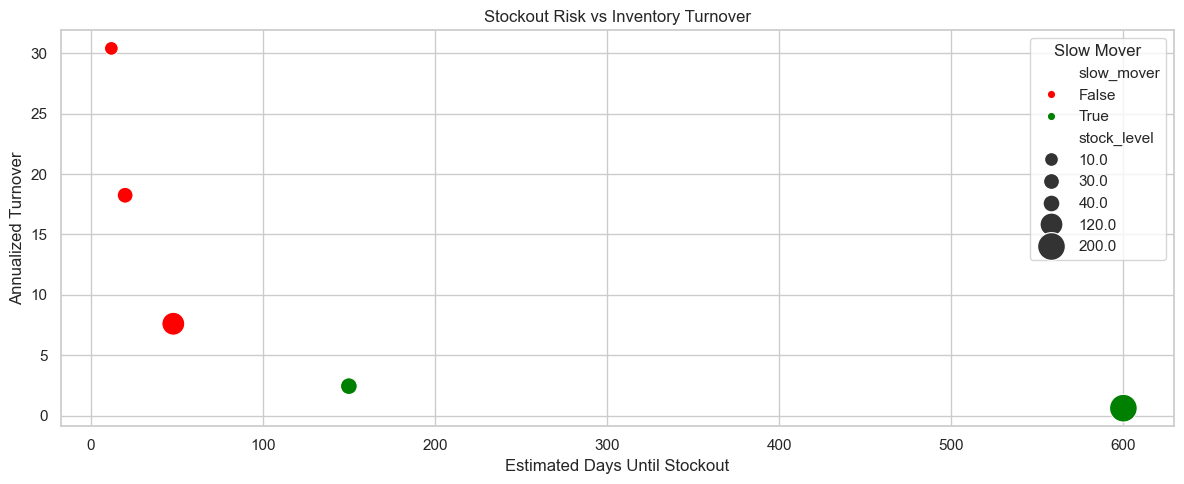

In [21]:
plot_inventory_analysis(inventory_metrics)


### Follow-up Prompts:
- Refined the prompt to explicitly request data validation and error handling for invalid or negative values.
- Added a second prompt asking for analysis of stockout risk and slow-moving product identification.

### Final Solution:
A validated retail inventory analysis workflow that computes annualized turnover and stockout risk, flags slow movers, and produces bar and scatter visualizations for manager review.

### Discussion Notes:
- Prompt framing: include specific data schema and task goals to ensure the generated code handles turnover, slow movers, stockout risk, and visualization.
- Date handling: validated last_restock_date and used 30-day sales to derive daily sales and risk windows.
- Error handling: explicit schema validation and non-negative checks prevent invalid numeric values.
- Visualization choice: bar charts for turnover by product and scatterplot for stockout risk vs turnover.


## Scenario 2: Website Analytics Debug

###  Prompt:
Debug the provided analyze_user_engagement function to fix impossible metrics, add data validation, compute correct session times, and create summary visualizations. Use the known issues (bounce rates over 100%, negative session times) as part of the prompt.

In [22]:
engagement_logs = pd.DataFrame([
    {'session_id': 'S001', 'device_type': 'mobile', 'duration': 120, 'page_views': 1},
    {'session_id': 'S001', 'device_type': 'mobile', 'duration': 60, 'page_views': 1},
    {'session_id': 'S002', 'device_type': 'desktop', 'duration': 300, 'page_views': 3},
    {'session_id': 'S003', 'device_type': 'tablet', 'duration': -20, 'page_views': 2},
    {'session_id': 'S004', 'device_type': 'desktop', 'duration': 180, 'page_views': 5},
    {'session_id': 'S005', 'device_type': 'mobile', 'duration': 240, 'page_views': 0},
])


In [23]:
def validate_engagement_df(df: pd.DataFrame) -> pd.DataFrame:
    required_cols = ['session_id', 'device_type', 'duration', 'page_views']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f'Missing engagement columns: {missing}')

    df = df.copy()
    df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
    df['page_views'] = pd.to_numeric(df['page_views'], errors='coerce').fillna(0).astype(int)
    df = df.dropna(subset=['session_id', 'device_type', 'duration'])
    df = df[(df['duration'] >= 0) & (df['page_views'] >= 0)]
    return df


In [24]:
def analyze_user_engagement(logs_df: pd.DataFrame):
    logs_df = validate_engagement_df(logs_df)
    session_summary = logs_df.groupby('session_id', as_index=False).agg({
        'duration': 'sum',
        'page_views': 'sum',
        'device_type': 'first'
    })
    total_sessions = len(session_summary)
    bounce_rate = (session_summary['page_views'] == 1).sum() / max(total_sessions, 1)
    avg_session_time = session_summary['duration'].mean()
    pages_per_session = session_summary['page_views'].mean()

    metrics = {
        'bounce_rate': bounce_rate,
        'avg_session_time': avg_session_time,
        'pages_per_session': pages_per_session,
        'total_sessions': total_sessions
    }

    device_metrics = logs_df.groupby('device_type', as_index=False).agg(
        session_id=('session_id', 'nunique'),
        duration=('duration', 'mean'),
        page_views=('page_views', 'sum')
    ).rename(columns={'session_id': 'unique_sessions'})

    return metrics, device_metrics, session_summary


In [25]:
metrics, device_metrics, session_summary = analyze_user_engagement(engagement_logs)
metrics, device_metrics, session_summary


({'bounce_rate': np.float64(0.0),
  'avg_session_time': np.float64(225.0),
  'pages_per_session': np.float64(2.5),
  'total_sessions': 4},
   device_type  unique_sessions  duration  page_views
 0     desktop                2     240.0           8
 1      mobile                2     140.0           2,
   session_id  duration  page_views device_type
 0       S001       180           2      mobile
 1       S002       300           3     desktop
 2       S004       180           5     desktop
 3       S005       240           0      mobile)

In [26]:
def plot_engagement_summary(metrics, device_metrics, session_summary):
    plt.figure(figsize=(8, 4))
    keys = ['bounce_rate', 'avg_session_time', 'pages_per_session']
    values = [metrics[k] for k in keys]
    sns.barplot(x=keys, y=values)
    plt.title('Key Engagement Metrics')
    plt.ylabel('Value')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.barplot(data=device_metrics, x='device_type', y='unique_sessions')
    plt.title('Unique Sessions by Device Type')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=session_summary, x='page_views', y='duration', hue='duration', palette='viridis', size='duration', sizes=(50, 300), legend=False)
    plt.title('Session Duration vs Pages Viewed')
    plt.xlabel('Total Page Views per Session')
    plt.ylabel('Total Session Duration (seconds)')
    plt.tight_layout()
    plt.show()


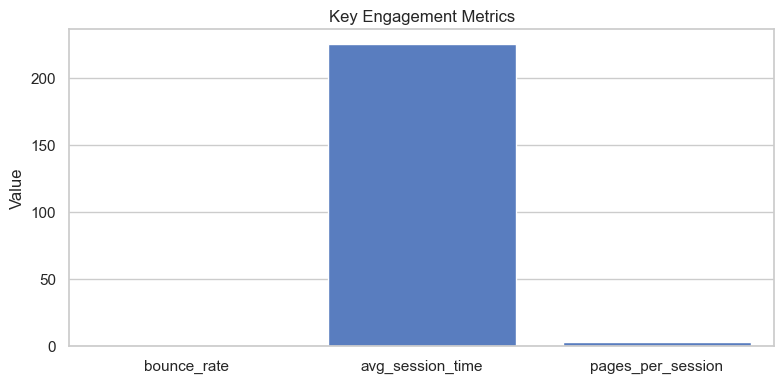

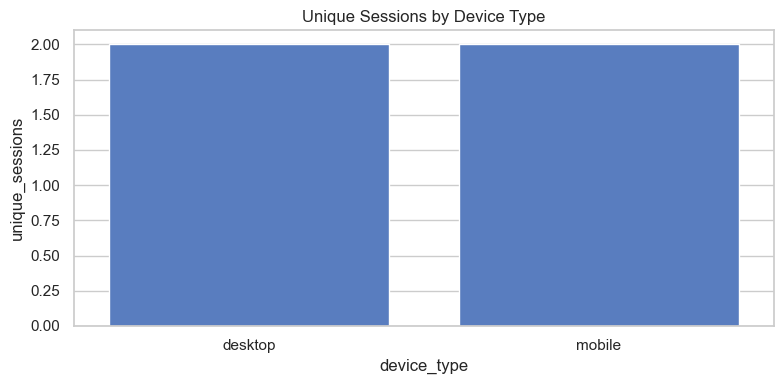

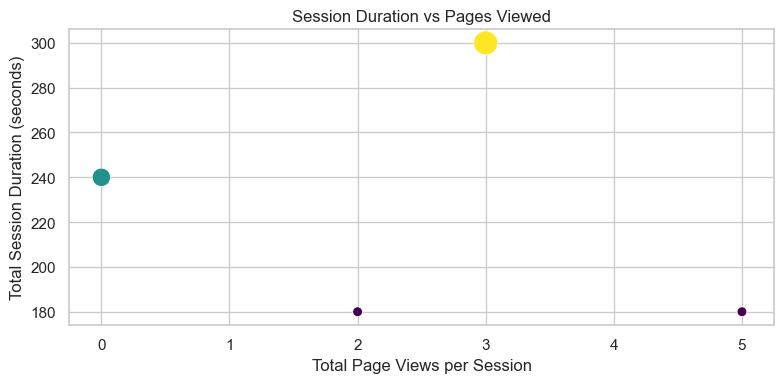

In [27]:
plot_engagement_summary(metrics, device_metrics, session_summary)


### Follow-up Prompts:
- Added a prompt asking the AI to explain the bug fix and validate headline metrics.
- Clarified that bounce rate must be based on session aggregation and negative durations must be removed.

### Final Solution:
A corrected engagement analysis with data validation, proper session-level time handling, safe bounce rate calculation, and summary visualizations.

### Discussion Notes:
- Prompt framing: included the broken function and impossible results so the debug task focuses on both logic and validation.
- Error identification: compared computed metrics with expected definitions and corrected bounce rate, session aggregation, and average duration.
- Validation methods: checked required columns, coerced numeric values, removed negative durations and page views, and ensured valid sessions.
- Time handling: aggregated `duration` at the session level and used session summaries instead of row-level averages.


## Scenario 3: Customer Segmentation Query

###  Prompt:
Generate an optimized SQL query that identifies active users who logged in within the last 30 days, filters to the top 20% of spenders, and returns their user preference trends from user_preferences. Include CTEs or window functions to keep the query readable and efficient.

In [28]:
sql_query = '''
WITH active_users AS (
    SELECT user_id, last_login_date, feature_usage_count, account_type
    FROM user_activity
    WHERE last_login_date >= CURRENT_DATE - INTERVAL '30 days'
),
spending_by_user AS (
    SELECT user_id, SUM(amount) AS total_spend
    FROM transactions
    GROUP BY user_id
),
ranked_spenders AS (
    SELECT user_id, total_spend, NTILE(5) OVER (ORDER BY total_spend DESC) AS spend_bucket
    FROM spending_by_user
),
high_value_users AS (
    SELECT user_id, total_spend
    FROM ranked_spenders
    WHERE spend_bucket = 1
),
selected_customers AS (
    SELECT au.user_id, au.last_login_date, au.feature_usage_count, au.account_type, hvu.total_spend
    FROM active_users au
    JOIN high_value_users hvu ON au.user_id = hvu.user_id
)
SELECT sc.user_id, sc.last_login_date, sc.feature_usage_count, sc.account_type, sc.total_spend,
       up.communication_preference, up.interface_theme, up.notification_settings
FROM selected_customers sc
LEFT JOIN user_preferences up ON sc.user_id = up.user_id
ORDER BY sc.total_spend DESC;
'''
print(sql_query)



WITH active_users AS (
    SELECT user_id, last_login_date, feature_usage_count, account_type
    FROM user_activity
    WHERE last_login_date >= CURRENT_DATE - INTERVAL '30 days'
),
spending_by_user AS (
    SELECT user_id, SUM(amount) AS total_spend
    FROM transactions
    GROUP BY user_id
),
ranked_spenders AS (
    SELECT user_id, total_spend, NTILE(5) OVER (ORDER BY total_spend DESC) AS spend_bucket
    FROM spending_by_user
),
high_value_users AS (
    SELECT user_id, total_spend
    FROM ranked_spenders
    WHERE spend_bucket = 1
),
selected_customers AS (
    SELECT au.user_id, au.last_login_date, au.feature_usage_count, au.account_type, hvu.total_spend
    FROM active_users au
    JOIN high_value_users hvu ON au.user_id = hvu.user_id
)
SELECT sc.user_id, sc.last_login_date, sc.feature_usage_count, sc.account_type, sc.total_spend,
       up.communication_preference, up.interface_theme, up.notification_settings
FROM selected_customers sc
LEFT JOIN user_preferences up ON sc.us

### Follow-up Prompts:
- Asked the AI to optimize the query using CTEs and top-percentile filtering rather than nested subqueries.
- Confirmed the query should return user preference trends for the high-value active customer set.

### Final Solution:
An efficient SQL query that selects active users from the last 30 days, filters to the top 20% of spenders via NTILE, and joins preference metadata for feature rollout analysis.

### Discussion Notes:
- Percentile handling: used NTILE(5) to identify the top 20% of spenders in a portable and explainable way.
- Date filtering: applied CURRENT_DATE - INTERVAL '30 days' to capture active users in the last 30 days.
- Optimization: split the logic into CTEs for active users, spending aggregation, ranking, and final join to preferences.
- Query readability: CTEs make each step explicit and easier to debug for feature rollout analysis.
